### 1 - Load Dataset and Imports 

In [78]:
# Imports
# Key libraries like scikit-learn, xgboost and imblearn are essential for this analysis 
# So if not installed ensure to do so before runninng this code 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, accuracy_score,brier_score_loss, roc_curve, 
                             precision_recall_curve, average_precision_score)
from xgboost import XGBClassifier
from tqdm import tqdm   


from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


RANDOM_STATE = 42

In [79]:
# Load dataset 
# set path variable to the path from which your downloaded dataset 
# is from using the download_data.py script 

path = "D:/Final Year/App Domains/Project/datasets/creditcard.csv"

df = pd.read_csv(path)

# Set time col and then the target col 
time_col   = "Time"  
target_col = "Class" 

# Quick validation and assertions 
print(df[[time_col, target_col]].head())

assert df.isna().sum().sum() == 0, "Dataset contains missing values"

fraud_ratio = df['Class'].mean()
assert fraud_ratio < 0.01, f"Fraud ratio unexpectedly high ({fraud_ratio:.4f})"


   Time  Class
0   0.0      0
1   0.0      0
2   1.0      0
3   1.0      0
4   2.0      0


### 2 - Temporal Split 

SCARFF - Carcillo et al. 2018

https://www.sciencedirect.com/science/article/abs/pii/S1566253517305444

In [80]:
# Define temporal train/test split (w/o leakage)

def temporal_train_test_split(
    df: pd.DataFrame,
    time_col: int,
    class_col: str,
    train_frac: float = 0.8):
    
    # Sort df by time_col, do a 80/20 temporal split.
    # Returns: X_train, y_train, X_test, y_test
    
    # Sort by time ascending
    df_sorted = df.sort_values(by=time_col).reset_index(drop=True)

    # Compute split index
    split_idx = int(len(df_sorted) * train_frac)

    # Split
    train_df = df_sorted.iloc[:split_idx].copy()
    test_df  = df_sorted.iloc[split_idx:].copy()

    # Separate features and target
    X_train = train_df.drop(columns=[class_col])
    y_train = train_df[class_col].copy()

    X_test  = test_df.drop(columns=[class_col])
    y_test  = test_df[class_col].copy()

    return X_train, y_train, X_test, y_test, df_sorted


### 3 - Baseline Modelling 



The  pipeline structure follows standard practices illustrated in scikit-learn documentation. 

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [81]:
# Temporal split and model training for dataset 

# Drop rows with missing time or target if necessary
df_clean = df.dropna(subset=[time_col, target_col]).copy()

# Temporal split
X_train, y_train, X_test, y_test, df_sorted = temporal_train_test_split(
    df_clean,
    time_col,
    target_col,
    train_frac=0.8
)

# Select feature columns (exclude time and target)
feature_cols = [c for c in X_train.columns if c not in [time_col, target_col]]

X_train_feat = X_train[feature_cols]
X_test_feat  = X_test[feature_cols]

# Define pipeline ******* DIFFERENT PIPELINES FOR IMPROVEMENTS ? 
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

# Fit model
pipeline.fit(X_train_feat, y_train)

# Quick baseline performance on test set
y_test_pre_p = pipeline.predict_proba(X_test_feat)[:, 1]
y_test_pre = (y_test_pre_p >= 0.5).astype(int)

auc  = roc_auc_score(y_test, y_test_pre_p)
acc  = accuracy_score(y_test, y_test_pre)
brier = brier_score_loss(y_test, y_test_pre_p)

print(f"Dataset 1 - Baseline temporal test AUC:   {auc:.3f}")
print(f"Dataset 1 - Baseline temporal test Acc:   {acc:.3f}")
print(f"Dataset 1 - Baseline temporal test Brier: {brier:.3f}")

Dataset 1 - Baseline temporal test AUC:   0.976
Dataset 1 - Baseline temporal test Acc:   0.999
Dataset 1 - Baseline temporal test Brier: 0.001


### 4 - Real Time Simulating 

Below is a combination of methodologies, extracted from StackOverflow discussing rolling AUC as welll as kaggle projects on simialr datasets. 

https://stackoverflow.com/questions/tagged/auc?tab=Frequent 

https://www.kaggle.com/code/mohammadfikri/credit-card-fraud-detection-roc-auc-95

In [82]:
# Function to simulate real-time predictions on a dataset

def simulate_realtime_predictions(
    df_sorted: pd.DataFrame,
    time_col: str,
    target_col: str,
    feature_cols: list,
    model,
    window_size: int = 50):

    df_sim = df_sorted.dropna(subset=[time_col, target_col]).copy()

    y_true_all = df_sim[target_col].values
    X_all      = df_sim[feature_cols]
    time_vals  = df_sim[time_col].values

    pred_probs = []
    pred_labels = []
    metrics_records = []

    
    for i in tqdm(range(len(df_sim)), desc="Simulating predictions"):
        x_row = X_all.iloc[i:i+1]
        proba = model.predict_proba(x_row)[:, 1][0]
        label_pred = int(proba >= 0.5)

        pred_probs.append(proba)
        pred_labels.append(label_pred)

        if i + 1 >= window_size:
            y_window = y_true_all[i+1-window_size:i+1]
            p_window = np.array(pred_probs[i+1-window_size:i+1])
            l_window = np.array(pred_labels[i+1-window_size:i+1])


            try:
                auc = roc_auc_score(y_window, p_window)
            except ValueError:
                auc = np.nan

            acc   = accuracy_score(y_window, l_window)
            brier = brier_score_loss(y_window, p_window)

            metrics_records.append({
                "end_index": i,
                "end_time_value": time_vals[i],
                "auc": auc,
                "accuracy": acc,
                "brier": brier
            })

    log_df = pd.DataFrame({
        "time_value": time_vals,
        "y_true": y_true_all,
        "y_pred_prob": pred_probs,
        "y_pred": pred_labels
    })

    metrics_df = pd.DataFrame(metrics_records)
    return log_df, metrics_df

In [83]:
# Assertions

assert X_train.shape[0] == y_train.shape[0], "Mismatch between X_train and y_train"
assert X_test.shape[0] == y_test.shape[0], "Mismatch between X_test and y_test"


In [7]:
# Apply real-time simulation to dataset 

log_df, metrics_df = simulate_realtime_predictions(
    df_sorted,
    time_col,
    target_col,
    feature_cols,
    model=pipeline,
    window_size=50)

# Roughly 12 mins for completion 

Simulating predictions: 100%|█████████████████████████████████████████████████| 284807/284807 [41:39<00:00, 113.93it/s]


In [84]:
log_df.head()
metrics_df.head()

,end_index,end_time_value,auc,accuracy,brier,auc_smooth
0,49,35.0,NaN,1.0,2.731607e-07,NaN
1,50,35.0,NaN,1.0,2.698021e-07,NaN
2,51,36.0,NaN,1.0,2.727428e-07,NaN
3,52,36.0,NaN,1.0,2.827295e-07,NaN
4,53,36.0,NaN,1.0,4.145078e-07,NaN


In [85]:
metrics_df.head()

,end_index,end_time_value,auc,accuracy,brier,auc_smooth
0,49,35.0,NaN,1.0,2.731607e-07,NaN
1,50,35.0,NaN,1.0,2.698021e-07,NaN
2,51,36.0,NaN,1.0,2.727428e-07,NaN
3,52,36.0,NaN,1.0,2.827295e-07,NaN
4,53,36.0,NaN,1.0,4.145078e-07,NaN


# Data Insights 

### Log DF
* time_value  = numeric time value, arriving in order representing a "live" feed.
* y_true = true label, thus far 0s meaning all negative class events.
* y_pred_prob = VERY small, models predicted probablity of a positive class. 
* y_pred = hard class prediction, once it is less than 0.5 it is hard code a 0. 

### Metrics DF
#### Each row is a rolling window of X amount of cases

* end_index = index of last case, self explanantory. 
* end_time_value = the time of the last case, multiple per second. 
* accuracy = thus far all predictions have been right. 
* Brier value = EXTREMELY small, expected as the model is predicting accurattely and therefore the proabblity error above is minimal. 
* auc = nan, both classes, rewuired therefore not present in the results from the first 5 rows, here is where we need to conduct the most analysis. 


In [86]:
# Remove any NaNs from low-information windows
metrics_clean = metrics_df.dropna(subset=["auc", "accuracy", "brier"]).copy()

# Choose number of chronological blocks (research often uses 20–50)
N_BLOCKS = 50

# Create 30 quantile-based time bins so each block has similar sample count
metrics_clean["time_bin"] = pd.qcut(metrics_clean["end_time_value"], q=N_BLOCKS)

# Compute midpoint of each time bin for plotting
metrics_clean["time_mid"] = metrics_clean["time_bin"].apply(lambda x: x.mid)

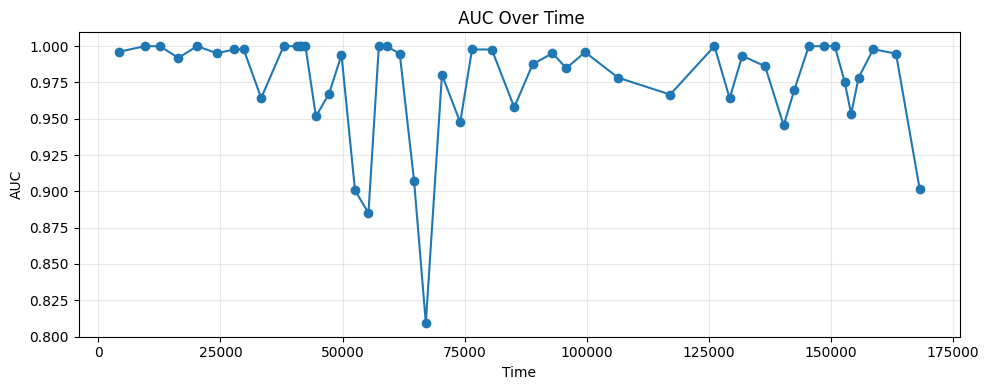

In [87]:
auc_block = (
    metrics_clean.groupby("time_bin", observed=False)["auc"]
    .mean()
    .reset_index()
)

auc_block["time_mid"] = auc_block["time_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 4))
plt.plot(auc_block["time_mid"], auc_block["auc"], marker="o")
plt.title(" AUC Over Time")
plt.xlabel("Time")
plt.ylabel("AUC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

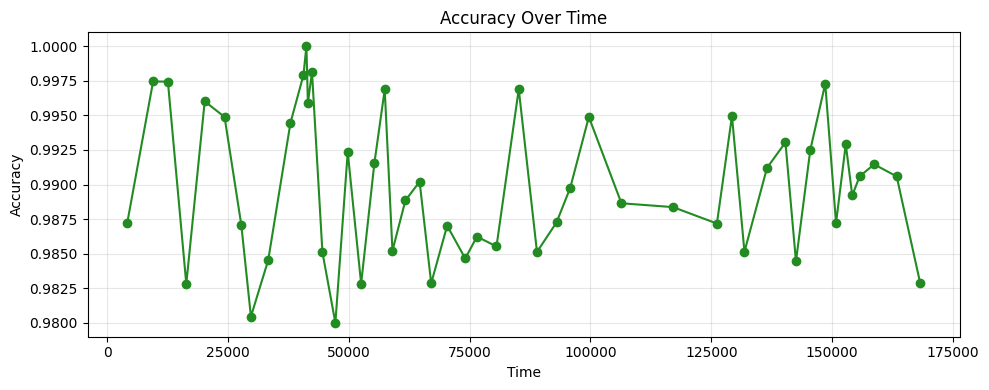

In [88]:
acc_block = (
    metrics_clean.groupby("time_bin", observed=False)["accuracy"]
    .mean()
    .reset_index()
)

acc_block["time_mid"] = acc_block["time_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 4))
plt.plot(acc_block["time_mid"], acc_block["accuracy"], marker="o", color="#228B22")
plt.title("Accuracy Over Time")
plt.xlabel("Time")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

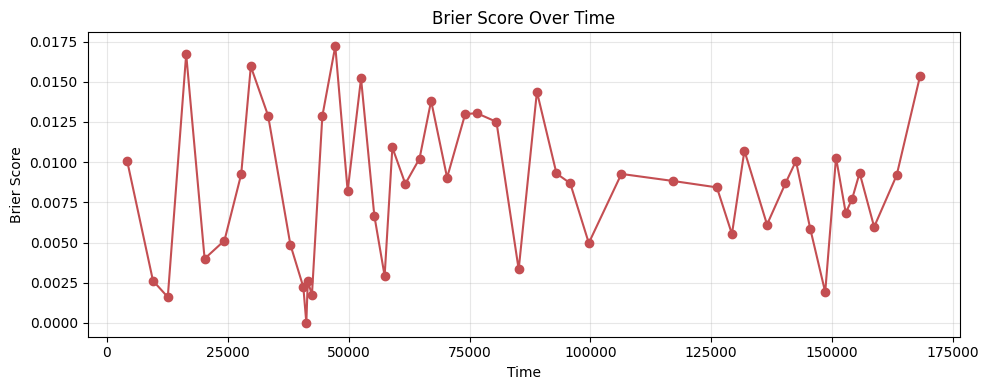

In [89]:
brier_block = (
    metrics_clean.groupby("time_bin", observed=False)["brier"]
    .mean()
    .reset_index()
)

brier_block["time_mid"] = brier_block["time_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 4))
plt.plot(brier_block["time_mid"], brier_block["brier"], marker="o", color="#C44E52")
plt.title("Brier Score Over Time")
plt.xlabel("Time")
plt.ylabel("Brier Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Visualistions Insights 

### AUC Graph 

* Mostly near 1.0 
* Sharp drops to as low as 0.1
* Partial Nans, as explained above, is when no presence of both classes is evident. In this imbanced case, its most likely all 0s. 
* High imbalance and possible local cluster of 1s 
* Sudden drops are due to presence of 1's, misranking and showcases AUCs sensiticity 
* Resurgence to 1.0 means net ranking is more accurate 

### Accuracy Graph 

* Mainly 0.98 - 1.0, somtimes around 0.92-0.95
* Reflecs class imbalance. 
* Due to Imbalnce this method is not so backed for the following reasoning. 
* As this is a 50 case window, if there are 49 negatives, 1 positive and the model predicts all negative, therefore misses the one and only positve class, it yields a 98% accuracy. NO GOOD TO US. 

### Brier score 

* Brier is measurement of calibration. 
* Low values indicate a low probability assignemnt to negatives and it being correct. 
* Brier score sikes as we see it surging from 0.01 ish to 0.08 indicates the model was very wrong about a positive test case. 
* Brier indicates just HOW BADLY wrong a prediction was of a positive case. 

* Brier is more sensitive than accuracy for early mistakes 
* Less sensitive than AUC to the rare severe ranking erros. 

# XG Boost Analysis 

Below are a combination of sources for which I utilised the implementation of XGBoost modelling 

https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

https://stackoverflow.com/questions/42793709/how-to-optimize-a-sklearn-pipeline-using-xgboost-for-a-different-eval-metric

In [16]:
pipeline_xgb = Pipeline([
    ("scaler", StandardScaler()),  
    ("xgb", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",     
        n_jobs=-1,
        scale_pos_weight=10       
    ))
])


In [17]:
neg, pos = np.bincount(y_train)
neg / pos

np.float64(545.3908872901678)

In [18]:
pipeline_xgb.fit(X_train_feat, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, random_state=None, ...))])

### Comparison Analysis 

In [72]:
y_test_pred_proba_xgb = pipeline_xgb.predict_proba(X_test_feat)[:, 1]
y_test_pred_xgb       = (y_test_pred_proba_xgb >= 0.5).astype(int)

auc_xgb   = roc_auc_score(y_test, y_test_pred_proba_xgb)
brier_xgb = brier_score_loss(y_test, y_test_pred_proba_xgb)

print(f"XGBoost - temporal test AUC:   {auc_xgb:.2f}")
print(f"XGBoost - temporal test Brier: {brier_xgb:.2f}")


XGBoost - temporal test AUC:   0.98
XGBoost - temporal test Brier: 0.00


In [73]:
print("LogReg vs XGBoost (test set)")
print(f"AUC   : {auc:.3f}  ->  {auc_xgb:.3f}")
print(f"Brier : {brier:.3f}  ->  {brier_xgb:.3f}")


LogReg vs XGBoost (test set)
AUC   : 0.976  ->  0.985
Brier : 0.001  ->  0.000


In [74]:
log_df_xgb, metrics_df_xgb = simulate_realtime_predictions(
    df_sorted,
    time_col,
    target_col,
    feature_cols,
    model=pipeline_xgb,
    window_size=50)

# May take up to 30 mins. 

Simulating predictions: 100%|█████████████████████████████████████████████████| 284807/284807 [30:46<00:00, 154.26it/s]


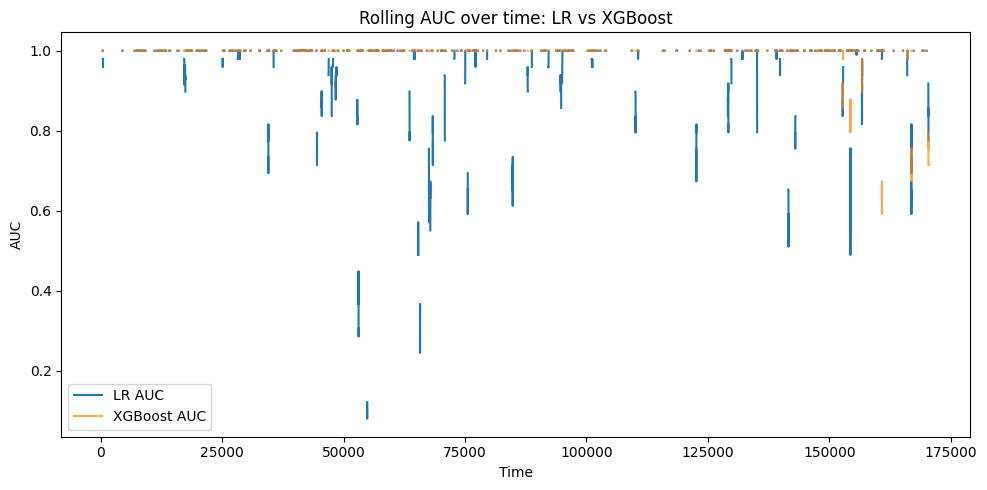

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(metrics_df["end_time_value"], metrics_df["auc"], label="LR AUC")
plt.plot(metrics_df_xgb["end_time_value"], metrics_df_xgb["auc"], label="XGBoost AUC", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("AUC")
plt.title("Rolling AUC over time: LR vs XGBoost")
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# Clean NaNs
lr = metrics_df.dropna(subset=["auc"]).copy()
xgb = metrics_df_xgb.dropna(subset=["auc"]).copy()

# How many time blocks to use
# N_BLOCKS = 50, from previous examples 

# Use common min/max time so LR & XGB share identical bins for compatibility
t_min = min(lr["end_time_value"].min(), xgb["end_time_value"].min())
t_max = max(lr["end_time_value"].max(), xgb["end_time_value"].max())

bins = np.linspace(t_min, t_max, N_BLOCKS + 1)

# Assign each window to a time block
lr["time_bin"]  = pd.cut(lr["end_time_value"], bins=bins, include_lowest=True)
xgb["time_bin"] = pd.cut(xgb["end_time_value"], bins=bins, include_lowest=True)


In [50]:
# Mean AUC per block
lr_block = (
    lr.groupby("time_bin", observed=False)["auc"]
      .mean()
      .reset_index()
      .rename(columns={"auc": "auc_lr"})
)

xgb_block = (
    xgb.groupby("time_bin", observed=False)["auc"]
       .mean()
       .reset_index()
       .rename(columns={"auc": "auc_xgb"})
)

# Merge so each block has LR & XGB AUC
auc_block = lr_block.merge(xgb_block, on="time_bin", how="inner")

# Midpoint of each bin for plotting on x-axis
auc_block["time_mid"] = auc_block["time_bin"].apply(lambda x: x.mid)


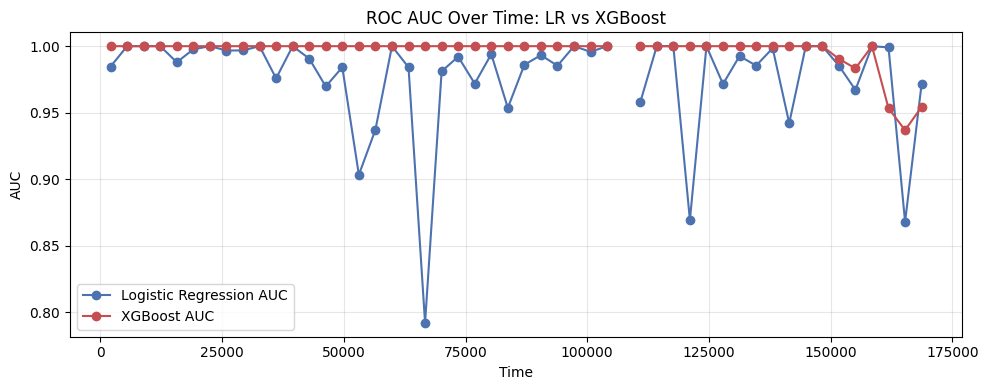

In [25]:
plt.figure(figsize=(10, 4))

plt.plot(
    auc_block["time_mid"],
    auc_block["auc_lr"],
    marker="o",
    label="Logistic Regression AUC",
    color="#4C72B0"   # baseline blue
)

plt.plot(
    auc_block["time_mid"],
    auc_block["auc_xgb"],
    marker="o",
    label="XGBoost AUC",
    color="#C44E52"   # deep red
)

plt.xlabel("Time")
plt.ylabel("AUC")
plt.title("ROC AUC Over Time: LR vs XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Q2 - Class Imbalance Handling Methods 


In Q1, we built a real-time fraud detection baseline using Logistic Regression and XGBoost 
with a temporal train/test split and rolling AUC/Brier metrics.

We now focus on **Research Question 2**:

> How effective are imbalance handling methods in improving fraud detection accuracy?

Using the *same dataset, temporal split, and feature set* from Q1, we will:
- keep the baseline Logistic Regression model,
- apply different imbalance handling strategies (undersampling, SMOTE, class weighting, etc.),
- compare their performance using AUC, Brier score and a PR Curve.

In [29]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """
    Fit the model on (X_train, y_train), evaluate on X_test.
    Returns a dict with key metrics.
    """
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    # Basic sanity checks
    assert len(y_proba) == len(y_test), "Prediction length mismatch"
    assert ((y_proba >= 0) & (y_proba <= 1)).all(), "Probabilities not in [0,1]"

    return {
        "model": name,
        "auc": roc_auc_score(y_test, y_proba),
        "brier": brier_score_loss(y_test, y_proba),
    }

Once again, modelling extracted from the scikit learn webpage not exclusively from the pipeline section but that wasa the main usage source 

In [30]:
# Baseline LR 
baseline_lr = ImbPipeline(steps=[
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Undersampling
undersampled_lr = ImbPipeline(steps=[
    ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# SMOTE oversampling
smote_lr = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Class-weighted LR
class_weight_lr = ImbPipeline(steps=[
    ("model", LogisticRegression(
        max_iter=1000, 
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

In [76]:
models = [
    ("Baseline LR", baseline_lr),
    ("Under-sampled LR", undersampled_lr),
    ("SMOTE LR", smote_lr),
    ("Class-weighted LR", class_weight_lr),
]

results = []
for name, mdl in models:
    print(f"Training {name}...")
    metrics = evaluate_model(name, mdl, X_train[feature_cols], y_train, X_test[feature_cols], y_test)
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df


Training Baseline LR...
Training Under-sampled LR...
Training SMOTE LR...
Training Class-weighted LR...


,model,auc,accuracy,brier
0,Baseline LR,0.977140,0.999350,0.000559
1,Under-sampled LR,0.984596,0.971086,0.026450
2,SMOTE LR,0.983349,0.981198,0.016002
3,Class-weighted LR,0.986209,0.973930,0.023390


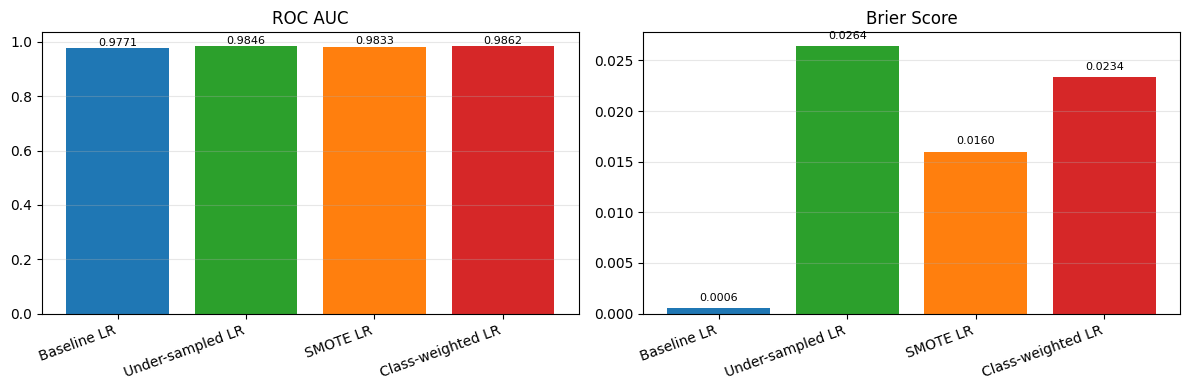

In [94]:

metrics = ["auc", "brier"]
titles = ["ROC AUC",
          "Brier Score"]
colours = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

x = np.arange(len(results_df))
model_names = results_df["model"].tolist()

for ax, metric, title in zip(axes, metrics, titles):
    values = results_df[metric].values
    bars = ax.bar(x, values,color=
                  colours)

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3)

    # Annotate values
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0005,
                f"{val:.4f}",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

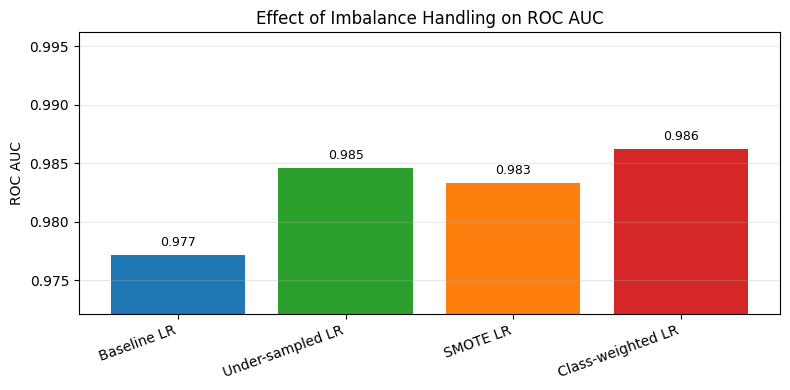

In [33]:
colours = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

x = np.arange(len(results_df))
model_names = results_df["model"].tolist()
auc_vals = results_df["auc"].values

plt.figure(figsize=(8, 4))
bars = plt.bar(x, auc_vals, color=colours)

plt.xticks(x, model_names, rotation=20, ha="right")
plt.ylabel("ROC AUC")
plt.title("Effect of Imbalance Handling on ROC AUC")

# Annotate 
for bar, val in zip(bars, auc_vals):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0005,
             f"{val:.3f}",
             ha="center", va="bottom", fontsize=9)

plt.ylim(min(auc_vals) - 0.005, max(auc_vals) + 0.01)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

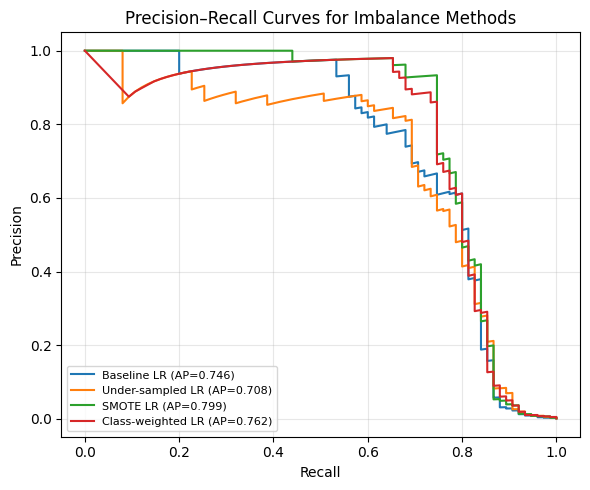

In [34]:
plt.figure(figsize=(6, 5))

for name, mdl in models:
    mdl.fit(X_train[feature_cols], y_train)
    y_proba = mdl.predict_proba(X_test[feature_cols])[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)

    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for Imbalance Methods")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Q3 - Static Classification vs Temporal Patterns 


So far, we have:
- built a real-time fraud detection baseline (Q1),
- investigated class imbalance handling methods (Q2).

We now address **Research Question 3**:

> Can temporal patterns in user behaviour improve detection in comparison to static classification?

To do this, we compare:
1. A **static XGBoost classifier** trained on randomly split transactions using only V1–V28 + Amount.
2. A **temporal XGBoost classifier** trained on earlier-in-time data and tested on later-in-time data, using V1–V28 + Amount + Time.

The dataset, preprocessing, and evaluation metrics remain the same for consistency.


In [35]:
# Features for the static model 
feature_cols_static = [col for col in df.columns if col.startswith("V")]
feature_cols_static.append("Amount")

X_static = df[feature_cols_static].values
y = df["Class"].values

print("Number of static features:", len(feature_cols_static))

# Randomised, stratified train/test split  for static
from sklearn.model_selection import train_test_split

X_train_static, X_test_static, y_train_static, y_test_static = train_test_split(
    X_static,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Static train shape:", X_train_static.shape)
print("Static test shape:", X_test_static.shape)


Number of static features: 29
Static train shape: (199364, 29)
Static test shape: (85443, 29)


In [36]:
# As seen previously, XGBoost was our best-performing model
static_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss", 
        n_jobs=-1,
        scale_pos_weight=(y_train_static == 0).sum() / max((y_train_static == 1).sum(), 1),
        random_state=RANDOM_STATE,
    ))
])

# Fit & evaluate 
static_pipeline.fit(X_train_static, y_train_static)

y_proba_static = static_pipeline.predict_proba(X_test_static)[:, 1]
y_pred_static  = (y_proba_static >= 0.5).astype(int)

auc_static   = roc_auc_score(y_test_static, y_proba_static)
brier_static = brier_score_loss(y_test_static, y_proba_static)

print("=== Static model (random split, no Time) ===")
print(f"AUC   : {auc_static:.3f}")
print(f"Brier : {brier_static:.4f}")


=== Static model (random split, no Time) ===
AUC   : 0.974
Acc   : 0.999
Brier : 0.0005


In [53]:
# Sort by time 
df_sorted = df.sort_values("Time").reset_index(drop=True)

# Features for temporal model – now includes Time
feature_cols_temp = [col for col in df.columns if col.startswith("V")]
feature_cols_temp.extend(["Amount", "Time"])

X_temp = df_sorted[feature_cols_temp].values
y_temp = df_sorted["Class"].values

print("Number of temporal features:", len(feature_cols_temp))

Number of temporal features: 30


In [54]:
# Temporal train/test split – early transactions for training, later for testing
train_frac = 0.7
split_idx = int(len(df_sorted) * train_frac)

X_train_temp = X_temp[:split_idx]
y_train_temp = y_temp[:split_idx]
X_test_temp  = X_temp[split_idx:]
y_test_temp  = y_temp[split_idx:]

print("Temporal train shape:", X_train_temp.shape)
print("Temporal test shape:", X_test_temp.shape)

Temporal train shape: (199364, 30)
Temporal test shape: (85443, 30)
Train time range: 0.0 -> 132928.0
Test time range : 132929.0 -> 172792.0


In [56]:
print("Train time range:", df_sorted["Time"].iloc[:split_idx].min(),
      "->", df_sorted["Time"].iloc[:split_idx].max())
print("Test time range :", df_sorted["Time"].iloc[split_idx:].min(),
      "->", df_sorted["Time"].iloc[split_idx:].max())

Train time range: 0.0 -> 132928.0
Test time range : 132929.0 -> 172792.0


In [57]:
# Define temporal XGBoost pipeline (same hyperparameters as static model)

neg_temp = (y_train_temp == 0).sum()
pos_temp = (y_train_temp == 1).sum()
imbalance_ratio_temp = neg_temp / max(pos_temp, 1)

temp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1,
        scale_pos_weight=imbalance_ratio_temp,
        random_state=RANDOM_STATE,
    ))
])

# Fit & evaluate 
temp_pipeline.fit(X_train_temp, y_train_temp)

y_proba_temp = temp_pipeline.predict_proba(X_test_temp)[:, 1]
y_pred_temp  = (y_proba_temp >= 0.5).astype(int)

auc_temp   = roc_auc_score(y_test_temp, y_proba_temp)
brier_temp = brier_score_loss(y_test_temp, y_proba_temp)

print("=== Temporal model (Time included) ===")
print(f"AUC   : {auc_temp:.3f}")
print(f"Brier : {brier_temp:.4f}")


=== Temporal model (Time included) ===
AUC   : 0.982
Acc   : 1.000
Brier : 0.0004


In [77]:
# Comparison table
results_q3 = pd.DataFrame({
    "Model": ["Static", "Temporal"],
    "AUC": [auc_static, auc_temp],
    "Brier": [brier_static, brier_temp],
})
results_q3


,Model,AUC,Brier
0,Static,0.973765,0.000528
1,Temporal,0.982364,0.000375


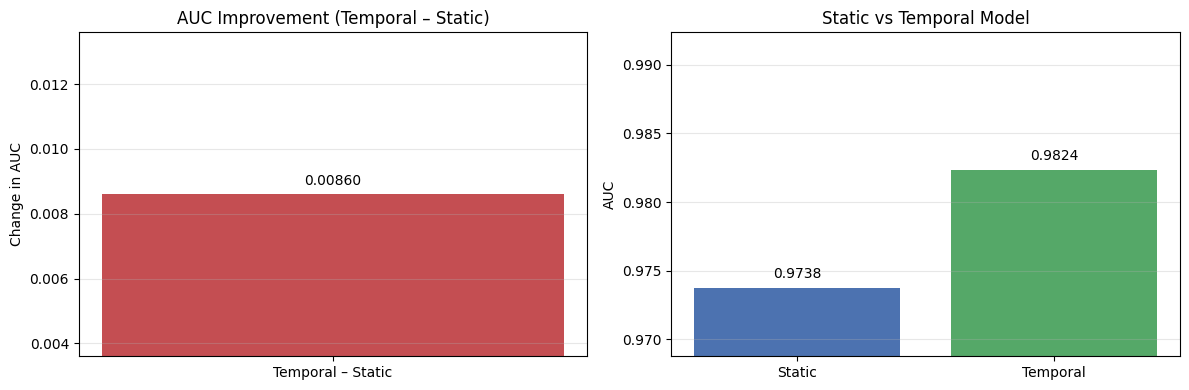

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AUC Difference
# ---------------------------------------
auc_diff = auc_temp - auc_static

axes[0].bar(["Temporal – Static"], [auc_diff], color="#C44E52")
axes[0].set_ylabel("Change in AUC")
axes[0].set_title("AUC Improvement (Temporal – Static)")

# Zoom around zero for greater visualisation insight
axes[0].set_ylim(auc_diff - 0.005, auc_diff + 0.005)

# Annotate value
axes[0].text(0, auc_diff + 0.0003, f"{auc_diff:.5f}", ha="center", fontsize=10)

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].grid(axis="y", alpha=0.3)

# Static vs Temporal AUC
# ---------------------------------------
bars = axes[1].bar(["Static", "Temporal"],
                   [auc_static, auc_temp],
                   color=["#4C72B0", "#55A868"])

axes[1].set_ylabel("AUC")
axes[1].set_title("Static vs Temporal Model")

# Annotate 
for bar, val in zip(bars, [auc_static, auc_temp]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10)

axes[1].set_ylim(min(auc_static, auc_temp) - 0.005,
                 max(auc_static, auc_temp) + 0.01)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


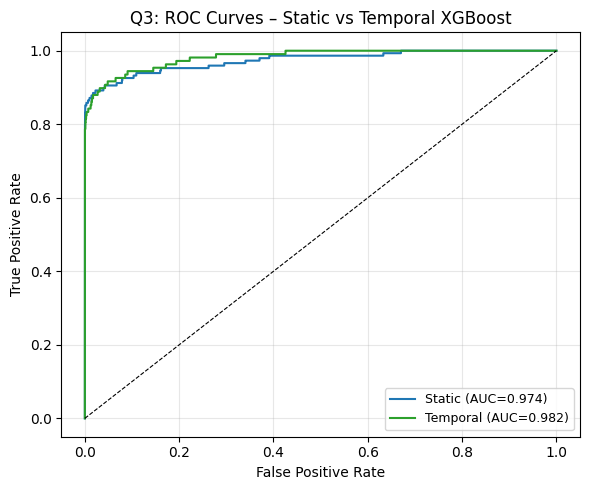

In [95]:
# Static ROC
fpr_static, tpr_static, _ = roc_curve(y_test_static, y_proba_static)
# Temporal ROC
fpr_temp, tpr_temp, _ = roc_curve(y_test_temp, y_proba_temp)

plt.figure(figsize=(6, 5))

plt.plot(fpr_static, tpr_static,
         label=f"Static (AUC={auc_static:.3f})",
         color="#1f77b4")

plt.plot(fpr_temp, tpr_temp,
         label=f"Temporal (AUC={auc_temp:.3f})",
         color="#2ca02c")

plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Q3: ROC Curves – Static vs Temporal XGBoost")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
